In [32]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

image_paths  = []

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.jpg'):
            image_paths.append(os.path.join(dirname,filename))

print(f'Total imags : {len(image_paths)}')

Total imags : 50000


In [33]:
print(image_paths[2000])
print(image_paths[49000])

/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.11328.jpg
/kaggle/input/dogs-vs-cats/train/cats/cat.8280.jpg


In [34]:
'/kaggle/input/dogs-vs-cats/train/cats/cat.8280.jpg'.split('/')[-2]

'cats'

Image dimensions (Height x Width x Channels): (127, 179, 3)


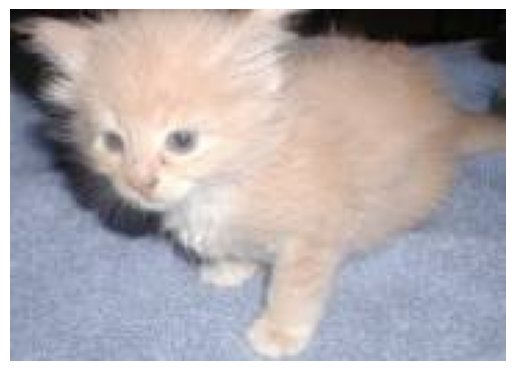

In [35]:
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg

img_sample_path = '/kaggle/input/dogs-vs-cats/train/cats/cat.8280.jpg'

img = mpimg.imread(img_sample_path)
print("Image dimensions (Height x Width x Channels):", img.shape)

plt.imshow(img)
plt.axis('off')
plt.show()

In [36]:
import pandas as pd 

df = pd.DataFrame({
    'filepath': image_paths , 
    'label' : [path.split('/')[-2] for path in image_paths]
})
df.sample(10)

,filepath,label
34801,/kaggle/input/dogs-vs-cats/train/dogs/dog.1068...,dogs
28429,/kaggle/input/dogs-vs-cats/test/cats/cat.9308.jpg,cats
18629,/kaggle/input/dogs-vs-cats/dogs_vs_cats/train/...,cats
38685,/kaggle/input/dogs-vs-cats/train/dogs/dog.1036...,dogs
10633,/kaggle/input/dogs-vs-cats/dogs_vs_cats/train/...,dogs
20849,/kaggle/input/dogs-vs-cats/dogs_vs_cats/train/...,cats
28144,/kaggle/input/dogs-vs-cats/test/cats/cat.6019.jpg,cats
22269,/kaggle/input/dogs-vs-cats/dogs_vs_cats/train/...,cats
43326,/kaggle/input/dogs-vs-cats/train/cats/cat.1211...,cats
44608,/kaggle/input/dogs-vs-cats/train/cats/cat.1160...,cats


In [37]:
from sklearn.model_selection import train_test_split
train_df , test_df = train_test_split(df , test_size = 0.2 , stratify = df['label'] , random_state = 42)

In [38]:
train_df

,filepath,label
38903,/kaggle/input/dogs-vs-cats/train/dogs/dog.9582...,dogs
22674,/kaggle/input/dogs-vs-cats/dogs_vs_cats/train/...,cats
46519,/kaggle/input/dogs-vs-cats/train/cats/cat.7039...,cats
22315,/kaggle/input/dogs-vs-cats/dogs_vs_cats/train/...,cats
19395,/kaggle/input/dogs-vs-cats/dogs_vs_cats/train/...,cats
...,...,...
30542,/kaggle/input/dogs-vs-cats/train/dogs/dog.9901...,dogs
24022,/kaggle/input/dogs-vs-cats/dogs_vs_cats/train/...,cats
48743,/kaggle/input/dogs-vs-cats/train/cats/cat.9167...,cats
42799,/kaggle/input/dogs-vs-cats/train/cats/cat.1198...,cats


In [39]:
import tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale = 1./255)

In [40]:
train_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(150, 150), 
    class_mode='binary', 
    batch_size=32,
    shuffle=True
)
val_gen = datagen.flow_from_dataframe(
    dataframe = test_df,
    x_col='filepath',
    y_col='label',
    target_size=(150, 150),
    class_mode='binary',
    batch_size=32,
    shuffle=False
)

Found 40000 validated image filenames belonging to 2 classes.
Found 10000 validated image filenames belonging to 2 classes.


In [41]:
from tensorflow import keras 
from keras.models import Sequential 
from keras.layers import Conv2D , MaxPooling2D , Flatten , Dense , Input , Dropout , BatchNormalization

model = Sequential([
    
    Input(shape = (150,150,3)) , 
    
    Conv2D(32 ,kernel_size =  (3,3) , activation = 'relu' , strides = 1 , padding = 'same'),
    BatchNormalization() ,   
    MaxPooling2D(pool_size = (2,2) , strides = 2) , 

    Conv2D(64,kernel_size =  (3, 3), activation='relu', strides=1, padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), strides=2),
    
    Conv2D(128,kernel_size =  (3, 3), activation='relu', strides=1, padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    Flatten() , 
    Dense(512 , activation = 'relu') , 
    Dropout(0.2) , 
    Dense(128 , activation = 'relu'),
    Dropout(0.2) , 

    Dense(1 , activation = 'sigmoid')

])
model.compile(optimizer = 'adam' , loss = 'binary_crossentropy' , metrics = ['accuracy'] )
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 150, 150, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 150, 150, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 75, 75, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 37, 37, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 37, 37, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 18, 18, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 41472)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 512)                 │      21,234,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,394,113 (81.61 MB)

 Trainable params: 21,393,665 (81.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [42]:
history = model.fit(train_gen , validation_data = val_gen , epochs = 4 )

Epoch 1/4


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 113s 85ms/step - accuracy: 0.6282 - loss: 1.2555 - val_accuracy: 0.7167 - val_loss: 0.5520
Epoch 2/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 112s 90ms/step - accuracy: 0.8045 - loss: 0.4320 - val_accuracy: 0.6292 - val_loss: 0.7318
Epoch 3/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 106s 84ms/step - accuracy: 0.8857 - loss: 0.2842 - val_accuracy: 0.8151 - val_loss: 0.4089
Epoch 4/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 105s 84ms/step - accuracy: 0.9511 - loss: 0.1341 - val_accuracy: 0.9107 - val_loss: 0.2834


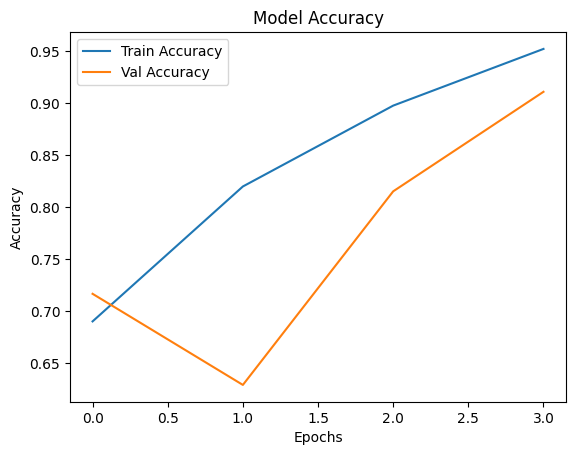

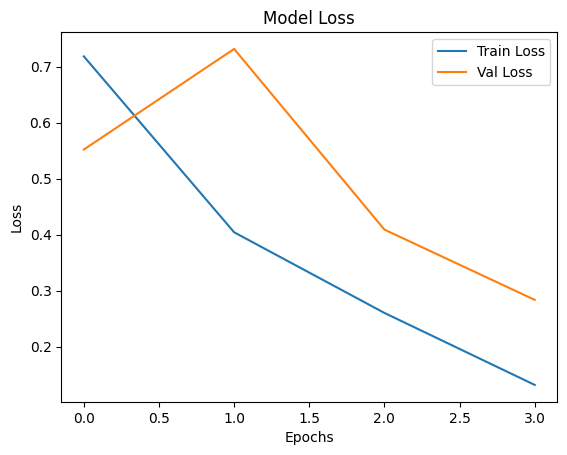

In [43]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.show()


In [44]:
!pip install pillow
!pip install requests


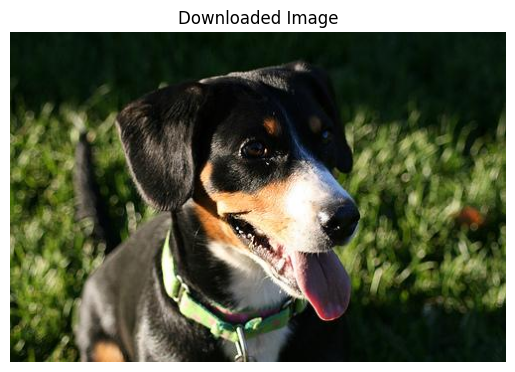

Shape: (333, 500, 3)


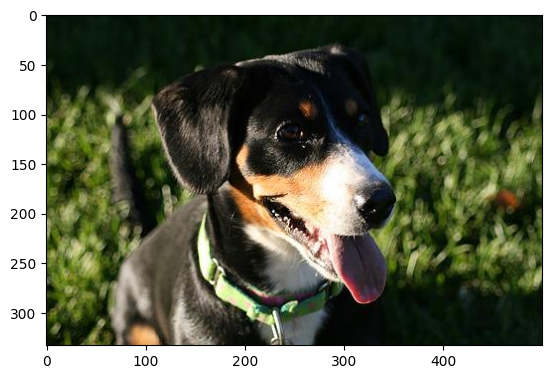

In [89]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import requests

# Get random cat image
# img_url = requests.get('https://api.thecatapi.com/v1/images/search').json()[0]['url']
# img_data = requests.get(img_url).content

# Random dog
img_url = requests.get('https://dog.ceo/api/breeds/image/random').json()['message']
img_data = requests.get(img_url).content

# Save and open image
with open('random_img.jpg', 'wb') as handler:
    handler.write(img_data)

img = Image.open('random_img.jpg')
plt.imshow(img)
plt.axis('off')
plt.title('Downloaded Image')
plt.show()

# Convert to array to get shape
img_array = np.array(img)
print("Shape:", img_array.shape)

img_resized = img.resize((150,150))
plt.imshow(img)

In [92]:
target_size = (150, 150)  # Change this based on your model

# Resize image
img_resized = img.resize(target_size)

# Convert to array and normalize
img_array = np.array(img_resized) / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)
print("Prediction:", prediction)

if prediction[0][0] >= 0.5:
    print("Predicted: Dog")
else:
    print("Predicted: Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Prediction: [[0.99805534]]
Predicted: Dog
